Q5 – GD(1/L), GD+backtracking, AGD, and Adaptive GD (BB1) on least squares.

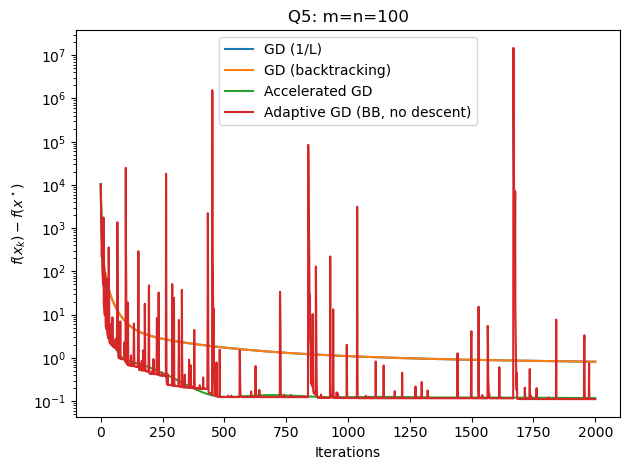

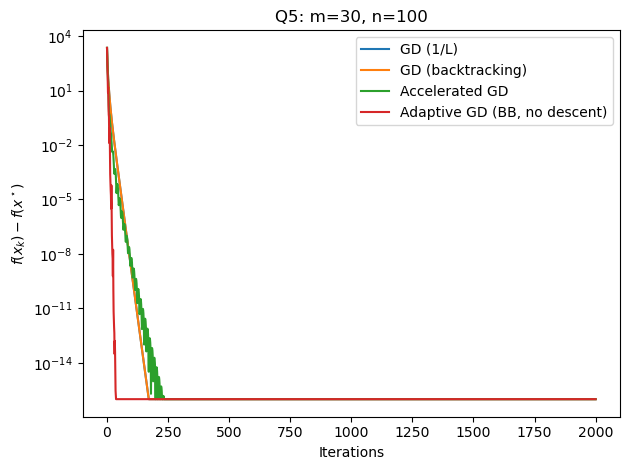

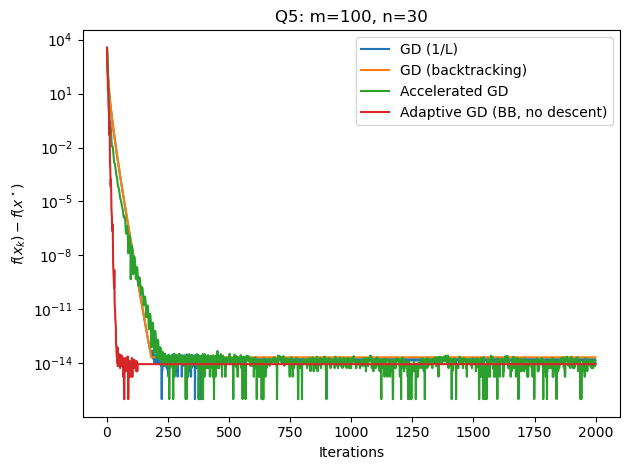

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def make_data(m, n, sigma=0.5, seed=42):
    rng = np.random.default_rng(seed)
    A = rng.standard_normal((m, n))
    w_true = rng.standard_normal(n)
    noise = rng.standard_normal(m) * sigma
    b = A @ w_true + noise
    return A, b

def f_ls(A, b, x):
    r = A @ x - b
    return float(r @ r)

def g_ls(A, b, x):
    r = A @ x - b
    return 2 * (A.T @ r)

def L_lipschitz(A):
    smax = np.linalg.svd(A, compute_uv=False)[0]
    return 2.0 * (smax**2)

# methods to compare
def gd_constant(A, b, x0, iters):
    L = L_lipschitz(A)
    t = 1.0 / L
    x = x0.copy()
    vals = []
    for _ in range(iters):
        vals.append(f_ls(A, b, x))
        x -= t * g_ls(A, b, x)
    vals.append(f_ls(A, b, x))
    return x, np.array(vals)

def gd_backtracking(A, b, x0, iters, t0=None, beta=0.8, c=1e-4):
    if t0 is None:
        t0 = 1.0 / L_lipschitz(A)
    x = x0.copy()
    vals = []
    for _ in range(iters):
        fx = f_ls(A, b, x)
        vals.append(fx)
        g = g_ls(A, b, x)
        t = t0
        g2 = float(g @ g)
        while True:
            x_new = x - t * g
            if f_ls(A, b, x_new) <= fx - c * t * g2:
                break
            t *= beta
        x = x_new
    vals.append(f_ls(A, b, x))
    return x, np.array(vals)

def accel_gd(A, b, x0, iters):
    L = L_lipschitz(A)
    t = 1.0 / L
    x = x0.copy()
    y = x0.copy()
    vals = []
    for k in range(1, iters + 1):
        vals.append(f_ls(A, b, x))
        g = g_ls(A, b, y)
        x_next = y - t * g
        theta = (k - 1) / (k + 2)
        y = x_next + theta * (x_next - x)
        x = x_next
    vals.append(f_ls(A, b, x))
    return x, np.array(vals)

def gd_bb(A, b, x0, iters, alpha0=None, clip=(1e-12, 1e12)):
    if alpha0 is None:
        alpha0 = 1.0 / L_lipschitz(A)
    x_prev = x0.copy()
    g_prev = g_ls(A, b, x_prev)
    alpha = alpha0
    x = x_prev - alpha * g_prev
    vals = [f_ls(A, b, x_prev)]
    for _ in range(1, iters):
        vals.append(f_ls(A, b, x))
        g = g_ls(A, b, x)
        s = x - x_prev
        y = g - g_prev
        sty = float(s @ y)
        sts = float(s @ s)
        if abs(sty) > 0:
            alpha = sts / max(sty, 1e-30)   # BB1
        alpha = float(np.clip(alpha, clip[0], clip[1]))
        x_next = x - alpha * g
        x_prev, x = x, x_next
        g_prev = g
    vals.append(f_ls(A, b, x))
    return x, np.array(vals)

def run_and_plot_q5(m, n, iters=2000, seed=42, title=""):
    A, b = make_data(m, n, seed=seed)
    x0 = np.zeros(n)
    x_star, *_ = np.linalg.lstsq(A, b, rcond=None)
    f_star = f_ls(A, b, x_star)

    _, v_gd  = gd_constant(A, b, x0, iters)
    _, v_bt  = gd_backtracking(A, b, x0, iters)
    _, v_agd = accel_gd(A, b, x0, iters)
    _, v_bb  = gd_bb(A, b, x0, iters)

    plt.figure()
    for label, vals in {
        "GD (1/L)": v_gd,
        "GD (backtracking)": v_bt,
        "Accelerated GD": v_agd,
        "Adaptive GD (BB, no descent)": v_bb,
    }.items():
        gap = np.maximum(vals - f_star, 1e-16)
        plt.semilogy(gap, label=label)
    plt.xlabel("Iterations")
    plt.ylabel(r"$f(x_k)-f(x^\star)$")
    plt.title(title or f"Q5  (m={m}, n={n})")
    plt.legend()
    plt.tight_layout()
    plt.show()

# run and plot
run_and_plot_q5(100, 100, iters=2000, title="Q5: m=n=100")
run_and_plot_q5(30, 100,  iters=2000, title="Q5: m=30, n=100")
run_and_plot_q5(100, 30,  iters=2000, title="Q5: m=100, n=30")


Q6 – Subgradient + AdaGrad for $\|Ax-b\|_2 + 0.1\|x\|_1$

[Q6 tuned] tau0≈0.1, eta≈0.3


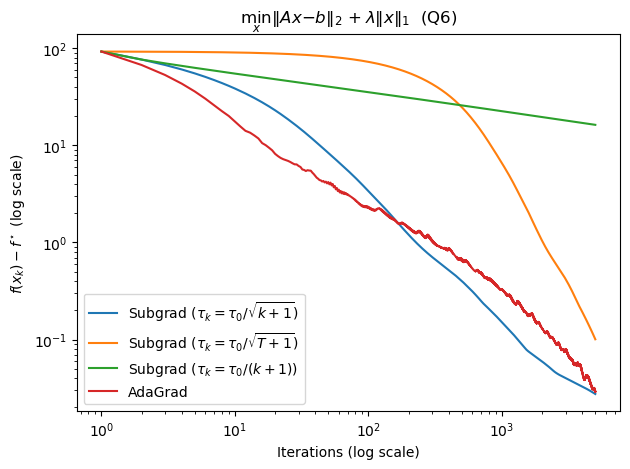

In [2]:
# ===================== Q6 =====================
import numpy as np
import matplotlib.pyplot as plt

def f_val_l1(A, b, x, lam=0.1):
    r = A @ x - b
    return float(np.linalg.norm(r, 2) + lam * np.linalg.norm(x, 1))

def subgrad_l1(A, b, x, lam=0.1):
    r = A @ x - b
    nr = np.linalg.norm(r, 2)
    u = r / nr if nr > 0 else np.zeros_like(r)
    s = np.sign(x)
    return A.T @ u + lam * s

def tau_sqrt(k, tau0):       # tau_k = tau0 / sqrt(k+1)
    return tau0 / np.sqrt(k + 1.0)

def tau_const_T(k, tau0, T): # tau_k = tau0 / sqrt(T+1)  (constant)
    return tau0 / np.sqrt(T + 1.0)

def tau_harmonic(k, tau0):   # tau_k = tau0 / (k+1)
    return tau0 / (k + 1.0)

def subgrad_descent(A, b, x0, iters, schedule, tau0, lam=0.1, T=None):
    x = x0.copy()
    vals = []
    for k in range(iters):
        vals.append(f_val_l1(A, b, x, lam))
        g = subgrad_l1(A, b, x, lam)
        t = schedule(k, tau0) if T is None else schedule(k, tau0, T)
        x = x - t * g
    vals.append(f_val_l1(A, b, x, lam))
    return x, np.array(vals)

def adagrad(A, b, x0, iters, eta=1.0, eps=1e-8, lam=0.1):
    x = x0.copy()
    G = np.zeros_like(x)
    vals = []
    for _ in range(iters):
        vals.append(f_val_l1(A, b, x, lam))
        g = subgrad_l1(A, b, x, lam)
        G += g * g
        x = x - eta * g / np.sqrt(G + eps)
    vals.append(f_val_l1(A, b, x, lam))
    return x, np.array(vals)

def rough_tune_tau0(A, b, x0, lam=0.1, iters_try=200, candidates=(3.0, 1.0, 0.3, 0.1)):
    best_tau0, best_val = None, np.inf
    for tau0 in candidates:
        _, vals = subgrad_descent(A, b, x0, iters_try, tau_sqrt, tau0, lam)
        if vals[-1] < best_val:
            best_val, best_tau0 = vals[-1], tau0
    return 1.0 if best_tau0 is None else best_tau0

def rough_tune_eta(A, b, x0, lam=0.1, iters_try=200, candidates=(3.0, 1.0, 0.3, 0.1)):
    best_eta, best_val = None, np.inf
    for eta in candidates:
        _, vals = adagrad(A, b, x0, iters_try, eta=eta, lam=lam)
        if vals[-1] < best_val:
            best_val, best_eta = vals[-1], eta
    return 1.0 if best_eta is None else best_eta

def solve_star_cvxpy_l1(A, b, lam=0.1):
    try:
        import cvxpy as cp
        n = A.shape[1]
        x = cp.Variable(n)
        obj = cp.norm(A @ x - b, 2) + lam * cp.norm1(x)
        prob = cp.Problem(cp.Minimize(obj))
        prob.solve(solver=cp.ECOS, verbose=False)
        if x.value is None:
            return None, None
        return np.array(x.value).reshape(-1), float(obj.value)
    except Exception:
        return None, None

def run_and_plot_q6(m=100, n=100, iters=5000, lam=0.1, seed=42, tune=True):
    A, b = make_data(m, n, seed=seed)
    x0 = np.zeros(n)
    tau0 = rough_tune_tau0(A, b, x0, lam, iters_try=min(200, iters//10)) if tune else 1.0
    eta  = rough_tune_eta(A, b, x0, lam, iters_try=min(200, iters//10))  if tune else 1.0
    print(f"[Q6 tuned] tau0≈{tau0}, eta≈{eta}")
    _, v_sqrt  = subgrad_descent(A, b, x0, iters, tau_sqrt,    tau0, lam)
    _, v_const = subgrad_descent(A, b, x0, iters, tau_const_T, tau0, lam, T=iters)
    _, v_harm  = subgrad_descent(A, b, x0, iters, tau_harmonic,tau0, lam)
    _, v_ada   = adagrad(A, b, x0, iters, eta=eta, lam=lam)

    _, f_star = solve_star_cvxpy_l1(A, b, lam)
    if f_star is None:
        f_star = float(min(v_sqrt.min(), v_const.min(), v_harm.min(), v_ada.min()))
        print(f"[Q6 proxy f*] {f_star:.6e}")

    plt.figure()
    curves = {
        r"Subgrad ($\tau_k=\tau_0/\sqrt{k+1}$)": v_sqrt,
        r"Subgrad ($\tau_k=\tau_0/\sqrt{T+1}$)": v_const,
        r"Subgrad ($\tau_k=\tau_0/(k+1)$)":      v_harm,
        r"AdaGrad":                               v_ada,
    }
    for label, vals in curves.items():
        k = np.arange(1, len(vals)+1)
        gap = np.maximum(vals - f_star, 1e-16)
        plt.loglog(k, gap, label=label)
    plt.xlabel("Iterations (log scale)")
    plt.ylabel(r"$f(x_k)-f^\star$ (log scale)")
    plt.title(r"$\min_x \|Ax-b\|_2 + \lambda\|x\|_1$  (Q6)")
    plt.legend(); plt.tight_layout(); plt.show()

# demo
run_and_plot_q6(m=100, n=100, iters=5000, lam=0.1, seed=42, tune=True)


Q7 – Subgradient + AdaGrad for $\|Ax-b\|_2 + (0.1/2)\|x\|_2^2$.

[Q7 tuned] tau0≈0.1, eta≈0.3, mu=0.1


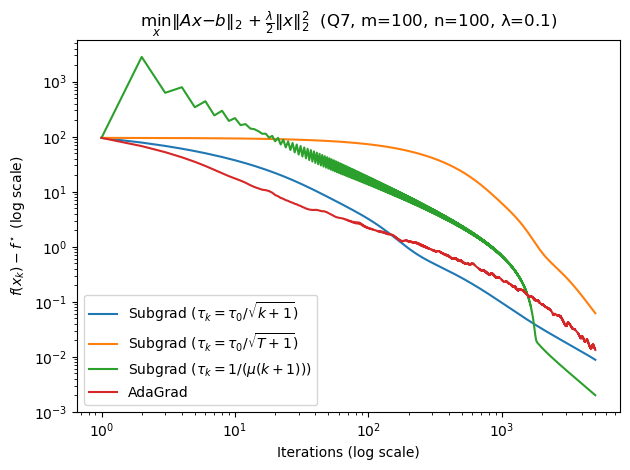

In [3]:
# ===================== Q7 =====================
import numpy as np
import matplotlib.pyplot as plt

def f_val_l2sq(A, b, x, lam=0.1):
    r = A @ x - b
    return float(np.linalg.norm(r, 2) + 0.5*lam * np.linalg.norm(x, 2)**2)

def subgrad_l2sq(A, b, x, lam=0.1):
    r = A @ x - b
    nr = np.linalg.norm(r, 2)
    u = r / nr if nr > 0 else np.zeros_like(r)
    return A.T @ u + lam * x  # strong convexity mu=lam

def tau_sqrt(k, tau0):
    return tau0 / np.sqrt(k + 1.0)

def tau_const_T(k, tau0, T):
    return tau0 / np.sqrt(T + 1.0)

def tau_strong(k, mu):
    return 1.0 / (mu * (k + 1.0))

def subgrad_descent2(A, b, x0, iters, schedule, arg, lam=0.1, T=None, is_mu=False):
    x = x0.copy()
    vals = []
    for k in range(iters):
        vals.append(f_val_l2sq(A, b, x, lam))
        g = subgrad_l2sq(A, b, x, lam)
        if is_mu:
            t = schedule(k, arg)  # arg is mu
        else:
            t = schedule(k, arg) if T is None else schedule(k, arg, T)  # arg is tau0
        x = x - t * g
    vals.append(f_val_l2sq(A, b, x, lam))
    return x, np.array(vals)

def adagrad2(A, b, x0, iters, eta=1.0, eps=1e-8, lam=0.1):
    x = x0.copy()
    G = np.zeros_like(x)
    vals = []
    for _ in range(iters):
        vals.append(f_val_l2sq(A, b, x, lam))
        g = subgrad_l2sq(A, b, x, lam)
        G += g * g
        x = x - eta * g / np.sqrt(G + eps)
    vals.append(f_val_l2sq(A, b, x, lam))
    return x, np.array(vals)

def rough_tune_tau0_2(A, b, x0, lam=0.1, iters_try=200, candidates=(3.0, 1.0, 0.3, 0.1)):
    best_tau0, best_val = None, np.inf
    for tau0 in candidates:
        _, vals = subgrad_descent2(A, b, x0, iters_try, tau_sqrt, tau0, lam)
        if vals[-1] < best_val:
            best_val, best_tau0 = vals[-1], tau0
    return 1.0 if best_tau0 is None else best_tau0

def rough_tune_eta_2(A, b, x0, lam=0.1, iters_try=200, candidates=(3.0, 1.0, 0.3, 0.1)):
    best_eta, best_val = None, np.inf
    for eta in candidates:
        _, vals = adagrad2(A, b, x0, iters_try, eta=eta, lam=lam)
        if vals[-1] < best_val:
            best_val, best_eta = vals[-1], eta
    return 1.0 if best_eta is None else best_eta

def solve_star_cvxpy_l2sq(A, b, lam=0.1):
    try:
        import cvxpy as cp
        n = A.shape[1]
        x = cp.Variable(n)
        obj = cp.norm(A @ x - b, 2) + 0.5*lam*cp.sum_squares(x)
        prob = cp.Problem(cp.Minimize(obj))
        prob.solve(solver=cp.ECOS, verbose=False)
        if x.value is None:
            return None, None
        return np.array(x.value).reshape(-1), float(obj.value)
    except Exception:
        return None, None

def run_and_plot_q7(m=100, n=100, iters=5000, lam=0.1, seed=42, tune=True):
    A, b = make_data(m, n, seed=seed)
    x0 = np.zeros(n)
    mu = lam
    tau0 = rough_tune_tau0_2(A, b, x0, lam, iters_try=min(200, iters//10)) if tune else 1.0
    eta  = rough_tune_eta_2(A, b, x0, lam, iters_try=min(200, iters//10))  if tune else 1.0
    print(f"[Q7 tuned] tau0≈{tau0}, eta≈{eta}, mu={mu}")
    _, v_sqrt  = subgrad_descent2(A, b, x0, iters, tau_sqrt,    tau0, lam)
    _, v_const = subgrad_descent2(A, b, x0, iters, tau_const_T, tau0, lam, T=iters)
    _, v_mu    = subgrad_descent2(A, b, x0, iters, tau_strong,  mu,   lam, is_mu=True)
    _, v_ada   = adagrad2(A, b, x0, iters, eta=eta, lam=lam)

    _, f_star = solve_star_cvxpy_l2sq(A, b, lam)
    if f_star is None:
        f_star = float(min(v_sqrt.min(), v_const.min(), v_mu.min(), v_ada.min()))
        print(f"[Q7 proxy f*] {f_star:.6e}")

    plt.figure()
    curves = {
        r"Subgrad ($\tau_k=\tau_0/\sqrt{k+1}$)": v_sqrt,
        r"Subgrad ($\tau_k=\tau_0/\sqrt{T+1}$)": v_const,
        r"Subgrad ($\tau_k=1/(\mu(k+1))$)":      v_mu,
        r"AdaGrad":                               v_ada,
    }
    for label, vals in curves.items():
        k = np.arange(1, len(vals)+1)
        gap = np.maximum(vals - f_star, 1e-16)
        plt.loglog(k, gap, label=label)
    plt.xlabel("Iterations (log scale)"); 
    plt.ylabel(r"$f(x_k)-f^\star$ (log scale)")
    title_math = r"$\min_x \|Ax-b\|_2 + \frac{\lambda}{2}\|x\|_2^2$"
    plt.title(title_math + f"  (Q7, m={m}, n={n}, λ={lam})")
    plt.legend(); plt.tight_layout(); plt.show()

# demo
run_and_plot_q7(m=100, n=100, iters=5000, lam=0.1, seed=42, tune=True)
